In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re
from nltk.corpus import stopwords
from collections import Counter

In [23]:
# function for pre processing

stopwords_english = set(stopwords.words("english"))

def preprocess_text(text: str) -> str:
    # lowercase
    text = text.lower()

    # remove non-alphabetical words / punctuations (keep spaces)
    text = re.sub(r"[^a-z\s]", "", text)

    # remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords_english]

    return " ".join(tokens)


In [24]:
# Load data, split and pre-process

# Download latest version
path = Path(kagglehub.dataset_download("nelgiriyewithana/emotions"))

df = pd.read_csv(path / "text.csv", index_col=0)

# Splitting and Pre-Processing
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])

# Pre-processing ( stop words and lowercase )
train_df["text_clean"] = train_df["text"].apply(preprocess_text)
test_df["text_clean"] = test_df["text"].apply(preprocess_text)

In [25]:
# Analyse Features

# Label Distribution - How many data points belongs to each emotion
emotion_counts = train_df["label"].value_counts().sort_index()
print("Emotion Count\n\n",emotion_counts)

train_df["text_length"] = train_df["text_clean"].str.split().str.len()

# short or long tweets
print("\nTweets length stats\n\n", train_df["text_length"].describe())


# Average Length of text per emotion
emotion_text_length_avg = train_df["text_length"].groupby(train_df["label"]).mean()
print("\nAverage Length of Text per Emotion\n\n", emotion_text_length_avg)

# Most frequent words
all_words = " ".join(train_df["text_clean"]).split()
word_counts = Counter(all_words)

print("\nFrequent Word count\n\n", word_counts.most_common(20))



Emotion Count

 label
0     96949
1    112853
2     27643
3     45854
4     38170
5     11978
Name: count, dtype: int64

Tweets length stats

 count    333447.000000
mean          9.359886
std           5.242880
min           0.000000
25%           5.000000
50%           8.000000
75%          12.000000
max          79.000000
Name: text_length, dtype: float64

Average Length of Text per Emotion

 label
0     9.055957
1     9.515086
2    10.052129
3     9.261591
4     9.218313
5     9.587494
Name: text_length, dtype: float64

Frequent Word count

 [('feel', 232011), ('feeling', 107409), ('like', 59187), ('im', 49496), ('really', 20701), ('know', 18887), ('time', 17012), ('get', 15670), ('little', 15360), ('people', 14624), ('would', 14366), ('want', 13146), ('one', 12769), ('think', 12659), ('still', 12657), ('ive', 11951), ('even', 11938), ('much', 11572), ('life', 11252), ('something', 10750)]


In [26]:
# Choosing and training model

# Model
model = LogisticRegression(max_iter=500)

# Get TF-IDF of the dataset
tf_idf_vectorizer = TfidfVectorizer()
x_train = tf_idf_vectorizer.fit_transform(train_df["text_clean"])
y_train = train_df["label"]

# Train
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

              precision    recall  f1-score   support

           0       0.94      0.94      0.94     24238
           1       0.91      0.93      0.92     28214
           2       0.80      0.75      0.77      6911
           3       0.89      0.90      0.90     11463
           4       0.84      0.84      0.84      9542
           5       0.75      0.69      0.72      2994

    accuracy                           0.89     83362
   macro avg       0.86      0.84      0.85     83362
weighted avg       0.89      0.89      0.89     83362



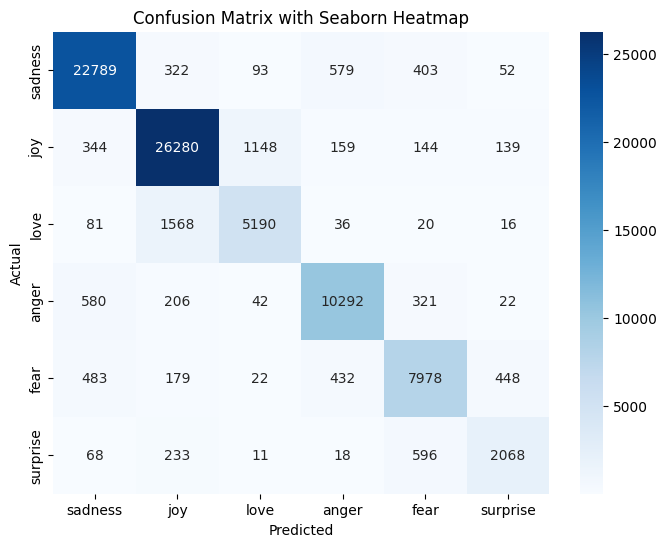

In [27]:
# Evaluate
classes = ('sadness', 'joy', 'love', 'anger', 'fear', 'surprise')
# Transforming test dataset
x_test = tf_idf_vectorizer.transform(test_df["text_clean"])
y_test = test_df["label"]
# Test
predictions = model.predict(x_test)

report = classification_report(y_test, predictions)
print(report)

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes) # Use 'd' for integer annotations
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with Seaborn Heatmap')
plt.show()